#MGT488-Deep Learning Lab Final Project

**Students:** Fatima, Nawal, Uswa
**Semester:** 7th-A  
**Submitted to:** Sir Saeed ur Rehman


### Project
In this project, we build a **Convolutional Variational Autoencoder (CVAE)** that:
1. Learns the visual features of fashion clothing images
2. Compresses them into a compact **latent space**
3. Reconstructs the images from that latent space
4. **Generates brand new synthetic fashion images** by sampling from the latent space

Think of the VAE as a smart compression system: it learns the "essence" of fashion images, then can create new ones from imagination.

## TASK 1
Dataset Acquisition & GPU Setup
###Mount Google Drive

In [5]:
from google.colab import files
import os

uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d vikashrajluhaniwal/fashion-images -p /content/fashion_raw --unzip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vikashrajluhaniwal/fashion-images
License(s): CC0-1.0
100% 335M/335M [00:03<00:00, 92.1MB/s]



In [6]:
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f'GPU Available: {gpu_name}')
    print('Make sure Runtime > Change runtime type > T4 GPU is selected!')
else:
    print('WARNING: No GPU found! Go to Runtime > Change runtime type > GPU (T4)')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice set to: {device}')

GPU Available: Tesla T4
Make sure Runtime > Change runtime type > T4 GPU is selected!

Device set to: cuda


TASK 2

In [27]:
import os
import shutil
import random
SOURCE_DIR = '/content/fashion_raw'
LOCAL_TRAIN = '/content/deepfashion/train_image'
LOCAL_TEST  = '/content/deepfashion/test_image'

os.makedirs(LOCAL_TRAIN, exist_ok=True)
os.makedirs(LOCAL_TEST,  exist_ok=True)

#collect images from Kaggle
all_images = []
for root, dirs, files in os.walk(SOURCE_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

print(f'Total images found: {len(all_images)}')

random.seed(42)
random.shuffle(all_images)

TRAIN_SUBSET_SIZE = min(3000, int(len(all_images) * 0.8))
train_imgs = all_images[:TRAIN_SUBSET_SIZE]
test_imgs  = all_images[TRAIN_SUBSET_SIZE:]

print(f'Train: {len(train_imgs)} | Test: {len(test_imgs)}')

#copy training subset
for img_path in train_imgs:
    dst = os.path.join(LOCAL_TRAIN, os.path.basename(img_path))
    if not os.path.exists(dst):
        shutil.copy(img_path, dst)

#copy test images
for img_path in test_imgs:
    dst = os.path.join(LOCAL_TEST, os.path.basename(img_path))
    if not os.path.exists(dst):
        shutil.copy(img_path, dst)

n_train = len(os.listdir(LOCAL_TRAIN))
n_test  = len(os.listdir(LOCAL_TEST))
print(f'Train: {n_train} | Test: {n_test}')

Total images found: 2906
Train: 2324 | Test: 582


TASK 3

In [29]:
from PIL import Image
import numpy as np

#pick a random image and inspect it
sample_imgs = os.listdir(LOCAL_TRAIN)[:5]

print('Checking image properties:')
for img_name in sample_imgs:
    img = Image.open(os.path.join(LOCAL_TRAIN, img_name))
    arr = np.array(img)
    print(f'{img_name}: Size={img.size}, Mode={img.mode}, Shape={arr.shape}')

print('DeepFashion images are RGB 3 channels')

Checking image properties:
2695.jpg: Size=(360, 480), Mode=RGB, Shape=(480, 360, 3)
8071.jpg: Size=(1080, 1440), Mode=RGB, Shape=(1440, 1080, 3)
3797.jpg: Size=(1080, 1440), Mode=RGB, Shape=(1440, 1080, 3)
41989.jpg: Size=(1800, 2400), Mode=RGB, Shape=(2400, 1800, 3)
41998.jpg: Size=(1800, 2400), Mode=RGB, Shape=(2400, 1800, 3)
DeepFashion images are RGB 3 channels


In [30]:
#resize: shrink to 64x64
#ToTensor: convert PIL Image [0,255] to tensor [0.0, 1.0]
#normalize: shift to [-1.0, 1.0] using mean=0.5, std=0.5
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

#image size keeping small to avoid pipeline bottleneck
IMG_SIZE    = 64
NUM_CHANNELS = 3  # RGB

#transform pipeline
transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5, 0.5, 0.5], std =[0.5, 0.5, 0.5])])
print(transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


In [31]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os

class FashionDataset(Dataset):
    """
    Custom Dataset for DeepFashion images.
    Loads images directly from a folder (no class subfolders needed).
    """
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform   = transform
        #getting list of all image file names in the folder
        self.image_files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        print(f'Dataset loaded: {len(self.image_files)} images from {folder_path}')

    def __len__(self):
        #total number of images
        return len(self.image_files)

    def __getitem__(self, idx):
        #load one image by index
        img_path = os.path.join(self.folder_path, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')  # Force 3 channels (RGB)
        if self.transform:
            image = self.transform(image)
        return image  #returns tensor of shape [3, 64, 64]


#train and Test datasets
train_dataset = FashionDataset(folder_path=LOCAL_TRAIN, transform=transform)
test_dataset  = FashionDataset(folder_path=LOCAL_TEST,  transform=transform)

Dataset loaded: 2906 images from /content/deepfashion/train_image
Dataset loaded: 582 images from /content/deepfashion/test_image


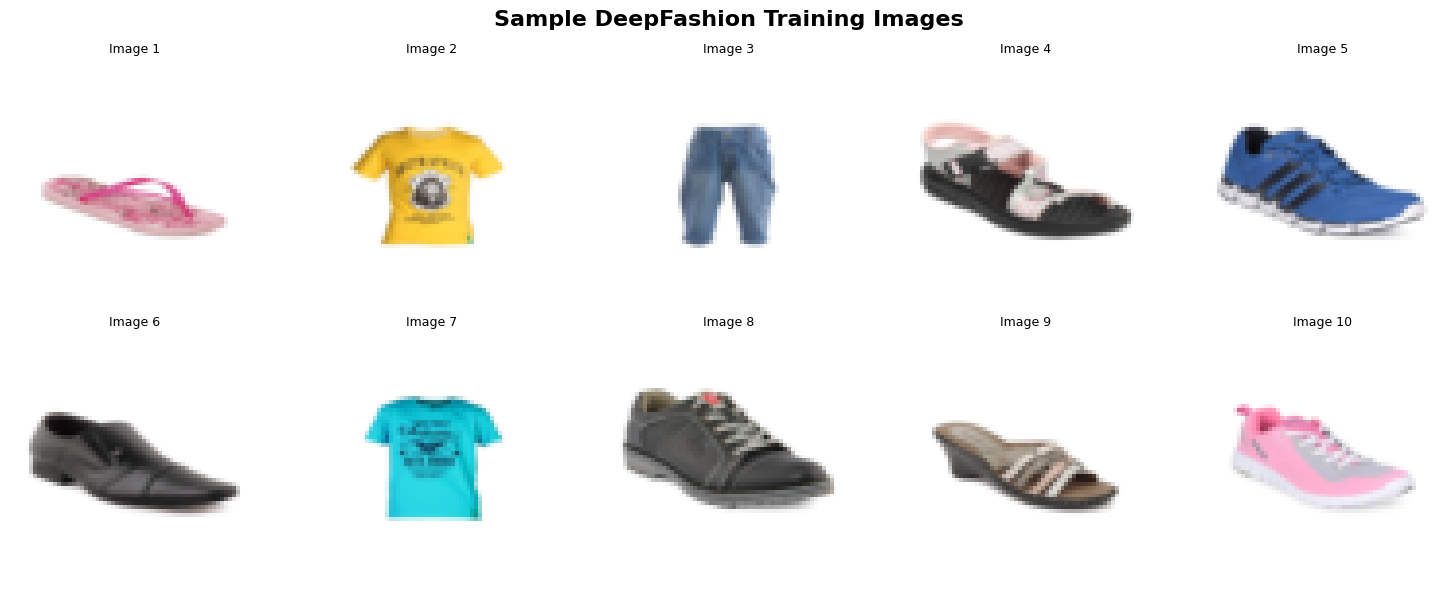

Sample images displayed (2 rows × 5 columns)


In [32]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    """
    Reverse the normalization so images display correctly.
    Normalized range [-1,1] --> back to [0,1] for matplotlib.
    Formula: pixel = (normalized * std) + mean
    """
    return tensor * 0.5 + 0.5

#pick 10 random samples for the grid 2 rows × 5 columns
num_samples = 10
indices = random.sample(range(len(train_dataset)), num_samples)
sample_images = [train_dataset[i] for i in indices]

#create the 2×5 grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample DeepFashion Training Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = denormalize(sample_images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.grid(False)
    ax.axis('off')
    ax.set_title(f'Image {i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sample images displayed (2 rows × 5 columns)')

TASK 4

In [33]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size  = BATCH_SIZE, shuffle = True, num_workers = 2)
test_loader = DataLoader(test_dataset,batch_size = BATCH_SIZE,shuffle = False,num_workers = 2)

print(f'Train DataLoader: {len(train_loader)} batches × {BATCH_SIZE} images = {len(train_dataset)} images')
print(f'Test  DataLoader: {len(test_loader)} batches × {BATCH_SIZE} images = {len(test_dataset)} images')
sample_batch = next(iter(train_loader))
print(f'\nBatch shape: {sample_batch.shape}  [batch_size, channels, height, width]')
print(f'Pixel value range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]  (should be ~[-1, 1])')

Train DataLoader: 46 batches × 64 images = 2906 images
Test  DataLoader: 10 batches × 64 images = 582 images

Batch shape: torch.Size([64, 3, 64, 64])  [batch_size, channels, height, width]
Pixel value range: [-1.00, 1.00]  (should be ~[-1, 1])


In [34]:
#TASK 5

import torch
import torch.nn as nn
import torch.nn.functional as F

LATENT_DIM = 128

class CVAE(nn.Module):
    """
    Convolutional Variational Autoencoder (CVAE)

    Encoder: 3 Conv2d layers → mu and logvar linear layers
    Decoder: 3 ConvTranspose2d layers (mirrored encoder) + Tanh output
    """

    def __init__(self, latent_dim=LATENT_DIM):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder_conv = nn.Sequential(
            #layer 1: [3, 64, 64] to [32, 32, 32]
            nn.Conv2d(in_channels=3,   out_channels=32,kernel_size=4, stride=2, padding=1),nn.ReLU(),
            #layer 2: [32, 32, 32] to [64, 16, 16]
            nn.Conv2d(in_channels=32,  out_channels=64,kernel_size=4, stride=2, padding=1),nn.ReLU(),
            #layer 3: [64, 16, 16] to [128, 8, 8]
            nn.Conv2d(in_channels=64,  out_channels=128,kernel_size=4, stride=2, padding=1),nn.ReLU())

        #after 3 conv layers: 128 channels × 8 × 8 = 8192 values
        self.flatten_size = 128 * 8 * 8  # = 8192
        self.fc_mu     = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

        # DECODER
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)

        self.decoder_conv = nn.Sequential(
            #layer 1: [128, 8, 8] to [64, 16, 16]
            nn.ConvTranspose2d(in_channels=128, out_channels=64,kernel_size=4, stride=2, padding=1),nn.ReLU(),
            # Layer 2: [64, 16, 16] to [32, 32, 32]
            nn.ConvTranspose2d(in_channels=64, out_channels=32,kernel_size=4, stride=2, padding=1),nn.ReLU(),
            # Layer 3: [32, 32, 32] to [3, 64, 64] back to original size
            #Tanh outputs values in [-1, 1]
            nn.ConvTranspose2d(in_channels=32, out_channels=3,kernel_size=4, stride=2, padding=1),nn.Tanh())
    def encode(self, x):
        """
        Encode input image into latent distribution parameters.
        Returns mu and logvar (NOT the sample z yet).
        """
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        mu     = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        REPARAMETERIZATION TRICK

        The trick: instead of sampling z directly (not differentiable),
        we compute: z = mu + std * epsilon
        where epsilon ~ N(0,1) is random noise.

        This keeps the randomness OUTSIDE the gradient computation,
        so backpropagation flows through mu and logvar (the learnable parts).

        std = exp(0.5 * logvar)  — we use log-variance for numerical stability
        """
        if self.training:
            std     = torch.exp(0.5 * logvar)
            epsilon = torch.randn_like(std)
            z = mu + std * epsilon
        else:
            z = mu
        return z

    def decode(self, z):
        """
        Decode latent vector z back into an image.
        """
        x = self.fc_decode(z)
        x = x.view(x.size(0), 128, 8, 8)
        x = self.decoder_conv(x)
        return x

    def forward(self, x):
        """
        Full forward pass: encode → reparameterize → decode
        Returns: reconstructed image, mu, logvar
        """
        mu, logvar   = self.encode(x)
        z            = self.reparameterize(mu, logvar)
        x_recon      = self.decode(z)
        return x_recon, mu, logvar
model = CVAE(latent_dim=LATENT_DIM).to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CVAE Model created and moved to: {device}')
print(f'Total trainable parameters: {total_params:,}')
print(model)

CVAE Model created and moved to: cuda
Total trainable parameters: 3,485,251
CVAE(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=8192, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [35]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    Combined VAE Loss = MSE Reconstruction + KL Divergence

    Args:
        recon_x : Reconstructed image from decoder [B, 3, 64, 64]
        x       : Original input image             [B, 3, 64, 64]
        mu      : Mean of latent distribution      [B, latent_dim]
        logvar  : Log variance of latent dist      [B, latent_dim]
        beta    : Weight for KL term (1.0 = standard VAE)
    """
    #MSE Loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    #KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    #total loss
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [36]:
import torch.optim as optim

LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

NUM_EPOCHS = 10
train_losses = []

print('Starting Training...')
print(f'Optimizer: Adam | Learning Rate: {LEARNING_RATE} | Epochs: {NUM_EPOCHS}')
print('='*65)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss    = 0

    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        #forward pass
        recon_images, mu, logvar = model(images)
        total_loss, recon_loss, kl_loss = vae_loss(recon_images, images, mu, logvar, beta=1.0)

        #backward pass & optimize
        optimizer.zero_grad()   #clear old gradients
        total_loss.backward()   #compute gradients
        optimizer.step()        #update weights

        #losses
        epoch_total_loss += total_loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kl_loss    += kl_loss.item()

    #avg loss per image
    n_images = len(train_dataset)
    avg_total = epoch_total_loss / n_images
    avg_recon = epoch_recon_loss / n_images
    avg_kl    = epoch_kl_loss    / n_images

    train_losses.append(avg_total)

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}] | '
          f'Total: {avg_total:8.2f} | '
          f'Recon (MSE): {avg_recon:8.2f} | '
          f'KL: {avg_kl:6.2f}')

print('='*65)

Starting Training...
Optimizer: Adam | Learning Rate: 0.001 | Epochs: 10
Epoch [ 1/10] | Total:  2528.50 | Recon (MSE):  2377.86 | KL: 150.63
Epoch [ 2/10] | Total:  1294.85 | Recon (MSE):  1267.07 | KL:  27.78
Epoch [ 3/10] | Total:  1004.62 | Recon (MSE):   964.77 | KL:  39.85
Epoch [ 4/10] | Total:   891.10 | Recon (MSE):   850.78 | KL:  40.33
Epoch [ 5/10] | Total:   804.82 | Recon (MSE):   760.01 | KL:  44.82
Epoch [ 6/10] | Total:   701.03 | Recon (MSE):   651.89 | KL:  49.14
Epoch [ 7/10] | Total:   604.23 | Recon (MSE):   549.58 | KL:  54.65
Epoch [ 8/10] | Total:   551.91 | Recon (MSE):   495.52 | KL:  56.40
Epoch [ 9/10] | Total:   521.09 | Recon (MSE):   464.06 | KL:  57.02
Epoch [10/10] | Total:   497.43 | Recon (MSE):   440.78 | KL:  56.65


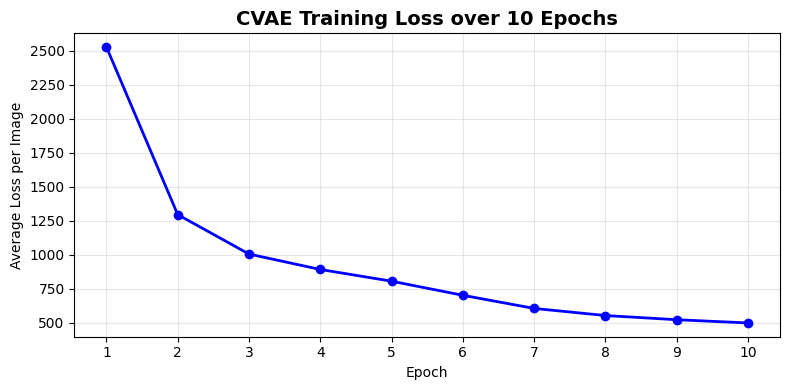

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', linewidth=2, markersize=6)
plt.title('CVAE Training Loss over 10 Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Average Loss per Image')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, NUM_EPOCHS+1))
plt.tight_layout()
plt.savefig('/content/training_loss.png', dpi=100)
plt.show()

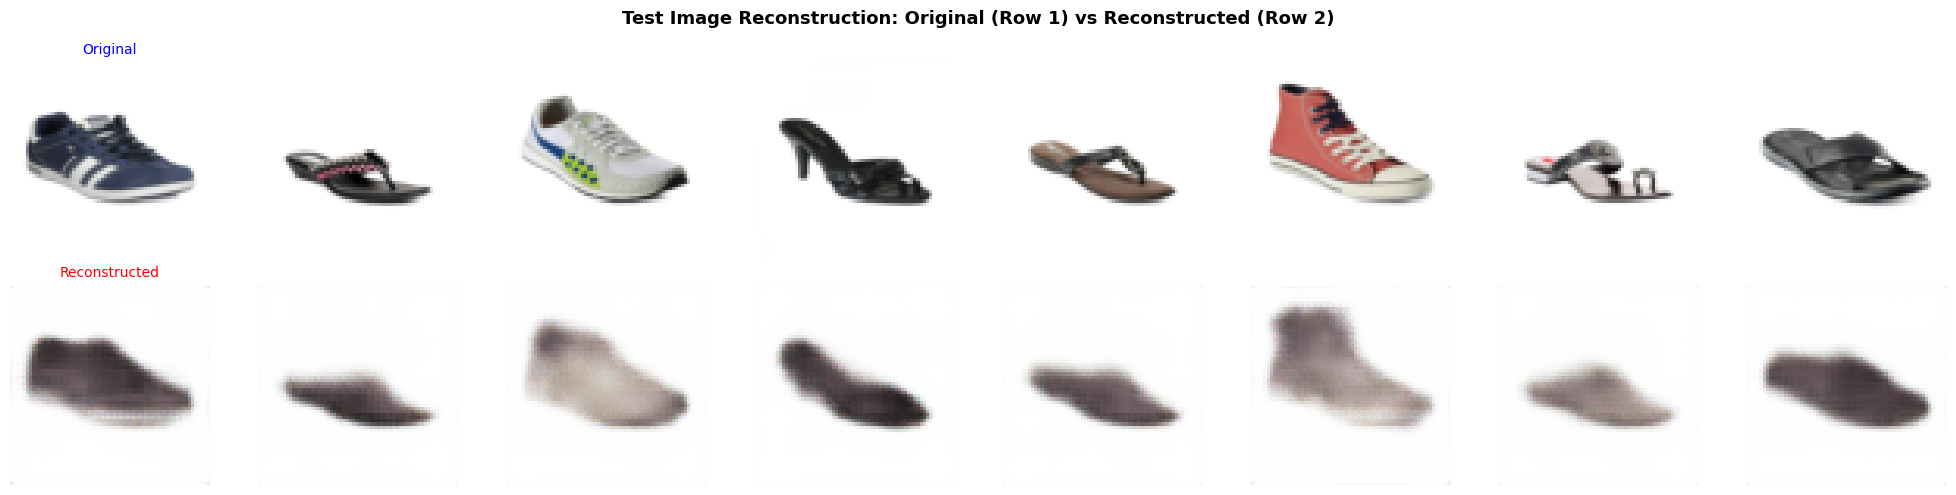

In [38]:
model.eval()

NUM_VIZ = 8   #number of images to show
test_images_batch = next(iter(test_loader))[:NUM_VIZ].to(device)
with torch.no_grad():
    recon_batch, _, _ = model(test_images_batch)
originals     = test_images_batch.cpu()
reconstructed = recon_batch.cpu()

fig, axes = plt.subplots(2, NUM_VIZ, figsize=(20, 5))
fig.suptitle('Test Image Reconstruction: Original (Row 1) vs Reconstructed (Row 2)',
             fontsize=13, fontweight='bold')

for i in range(NUM_VIZ):
    orig_img = denormalize(originals[i]).permute(1, 2, 0).numpy()
    orig_img = np.clip(orig_img, 0, 1)
    axes[0, i].imshow(orig_img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=11, fontweight='bold')

    recon_img = denormalize(reconstructed[i]).permute(1, 2, 0).numpy()
    recon_img = np.clip(recon_img, 0, 1)
    axes[1, i].imshow(recon_img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontsize=11, fontweight='bold')

axes[0, 0].set_title('Original', fontsize=10, color='blue')
axes[1, 0].set_title('Reconstructed', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('/content/reconstruction_results.png', dpi=120, bbox_inches='tight')
plt.show()

TASK 6

In [39]:
SAVE_PATH = '/content/cvae_model.pth'

torch.save({'model_state_dict': model.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
            'latent_dim': LATENT_DIM,'train_losses': train_losses, 'epochs_trained': NUM_EPOCHS,}, SAVE_PATH)
print(f'Model saved to: {SAVE_PATH}')

Saved Model

In [42]:
loaded_model = CVAE(latent_dim=LATENT_DIM).to(device)

checkpoint = torch.load(SAVE_PATH, map_location=device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
loaded_model.eval()

print(f'Model loaded from: {SAVE_PATH}')
print(f'Epochs trained: {checkpoint["epochs_trained"]}')
print(f'Latent dimension: {checkpoint["latent_dim"]}')
print('Model is ready for inference!')

Model loaded from: /content/cvae_model.pth
Epochs trained: 10
Latent dimension: 128
Model is ready for inference!


generate synthetic fashion images

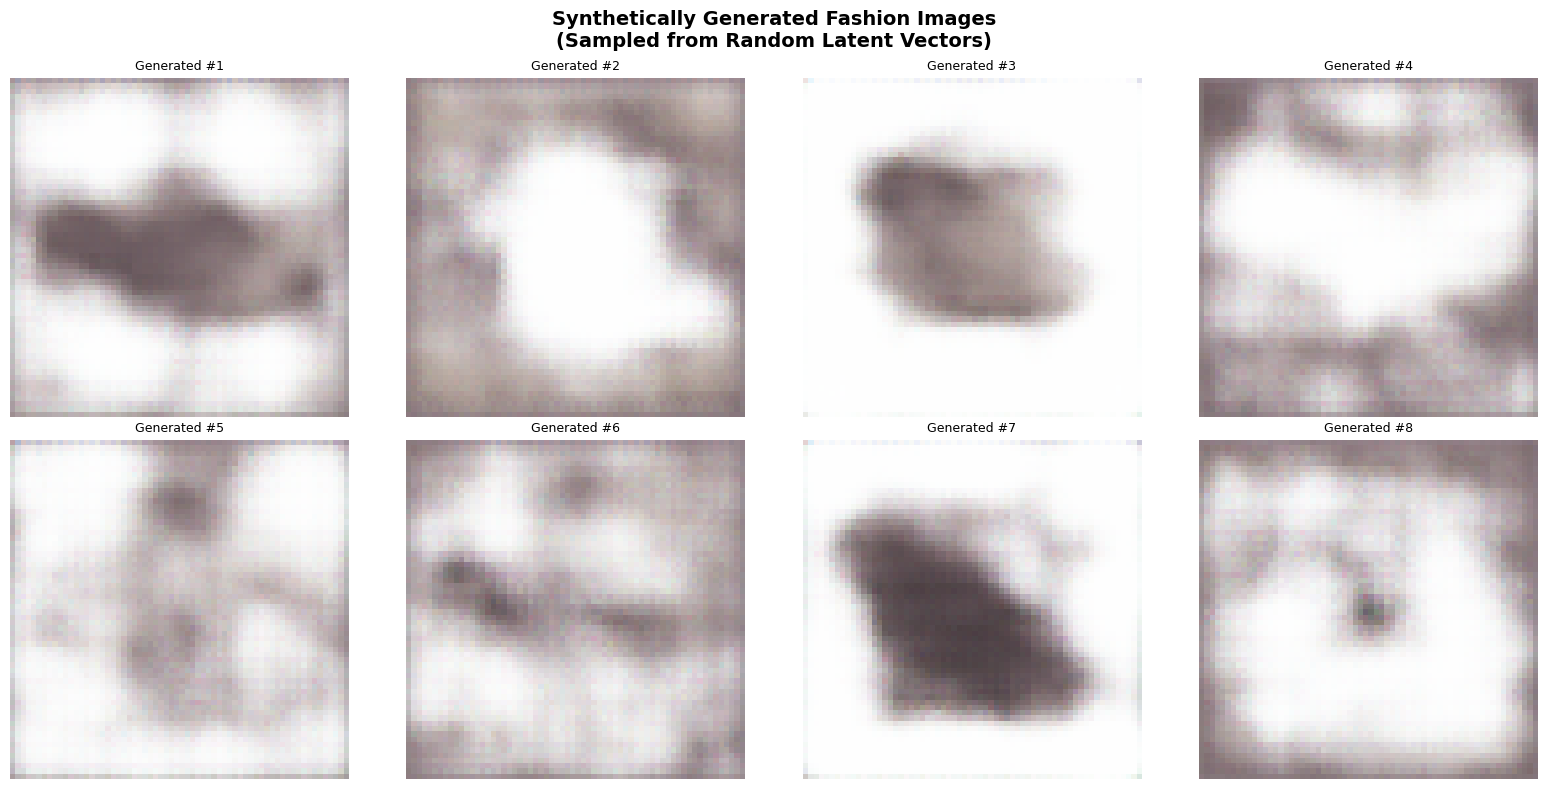

8 synthetic fashion images generated and saved!


In [43]:
NUM_GENERATED = 8

with torch.no_grad():
    random_z = torch.randn(NUM_GENERATED, LATENT_DIM).to(device)
    synthetic_images = loaded_model.decode(random_z)

synthetic_images = synthetic_images.cpu()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Synthetically Generated Fashion Images\n(Sampled from Random Latent Vectors)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    gen_img = denormalize(synthetic_images[i]).permute(1, 2, 0).numpy()
    gen_img = np.clip(gen_img, 0, 1)
    ax.imshow(gen_img)
    ax.axis('off')
    ax.set_title(f'Generated #{i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('/content/synthetic_fashion_images.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'{NUM_GENERATED} synthetic fashion images generated and saved!')

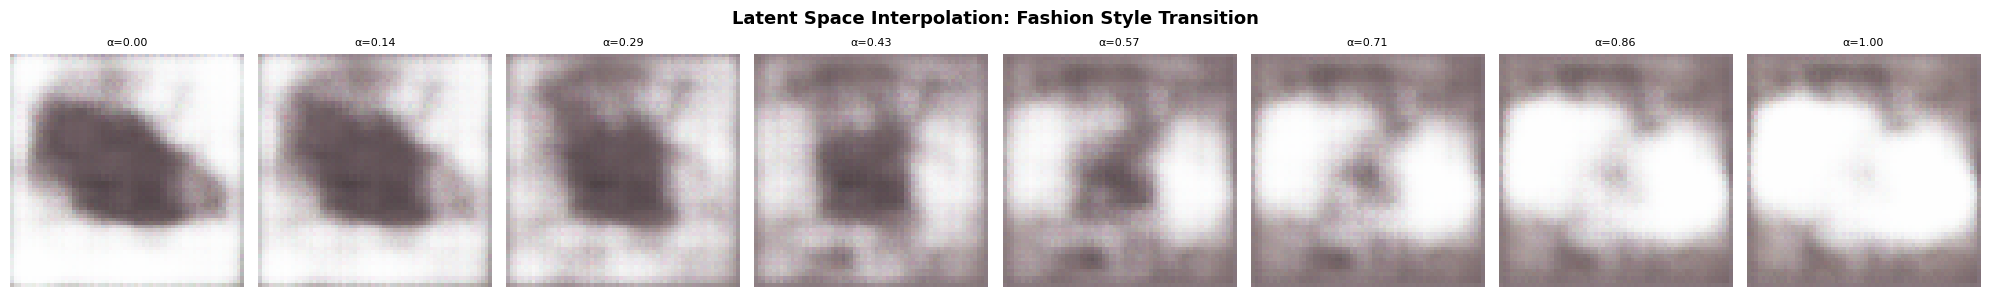

Latent space interpolation displayed!


In [44]:
#Latent Space Interpolation
NUM_STEPS = 8

with torch.no_grad():
    z_start = torch.randn(1, LATENT_DIM).to(device)
    z_end   = torch.randn(1, LATENT_DIM).to(device)
    alphas = torch.linspace(0, 1, NUM_STEPS)
    interpolated = []

    for alpha in alphas:
        z_interp = (1 - alpha) * z_start + alpha * z_end
        img = loaded_model.decode(z_interp)
        interpolated.append(img.cpu())

fig, axes = plt.subplots(1, NUM_STEPS, figsize=(20, 3))
fig.suptitle('Latent Space Interpolation: Fashion Style Transition',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes):
    img = denormalize(interpolated[i][0]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'α={alphas[i]:.2f}', fontsize=8)

plt.tight_layout()
plt.savefig('/content/latent_interpolation.png', dpi=120)
plt.show()
print('Latent space interpolation displayed!')

In [45]:
print('SUMMARY')
print(f'Training Images Used  : {len(train_dataset):,}')
print(f'Test Images           : {len(test_dataset):,}')
print(f'Image Size            : {IMG_SIZE}×{IMG_SIZE} pixels')
print(f'Image Channels        : {NUM_CHANNELS} (RGB)')
print(f'Latent Dimension      : {LATENT_DIM}')
print(f'Batch Size            : {BATCH_SIZE}')
print(f'Optimizer             : Adam (lr={LEARNING_RATE})')
print(f'Epochs Trained        : {NUM_EPOCHS}')
print(f'Final Training Loss   : {train_losses[-1]:.2f}')
print(f'Total Parameters      : {total_params:,}')
print(f'Model Saved To        : {SAVE_PATH}')
print('Outputs saved:')
print('  /content/sample_images.png')
print('  /content/training_loss.png')
print('  /content/reconstruction_results.png')
print('  /content/synthetic_fashion_images.png')
print('  /content/latent_interpolation.png')
print(f'IMG_SIZE        : {IMG_SIZE}×{IMG_SIZE}')
print(f'Flatten size    : {FLATTEN_SIZE:,} values')
print(f'Total params    : {total_params:,}')
print(f'Train images    : {len(train_dataset)}')
print(f'Final loss      : {train_losses[-1]:.2f}')
print(f'Total train time: {total_time:.1f}s')

print(f'current run ({IMG_SIZE}×{IMG_SIZE}):')
if   IMG_SIZE == 64:
    print('Baseline. Images will look soft/blurry.')
elif IMG_SIZE == 128:
    print('Good balance. Noticeably sharper than 64.')
elif IMG_SIZE == 256:
    print('Sharp images. Check if training time was acceptable.')
elif IMG_SIZE == 512:
    print('WARNING: If you got here, check GPU memory usage.')
else:
    print(f'Custom size {IMG_SIZE}. Observe output quality manually.')

SUMMARY
Training Images Used  : 2,906
Test Images           : 582
Image Size            : 64×64 pixels
Image Channels        : 3 (RGB)
Latent Dimension      : 128
Batch Size            : 64
Optimizer             : Adam (lr=0.001)
Epochs Trained        : 10
Final Training Loss   : 497.43
Total Parameters      : 3,485,251
Model Saved To        : /content/cvae_model.pth
Outputs saved:
  /content/sample_images.png
  /content/training_loss.png
  /content/reconstruction_results.png
  /content/synthetic_fashion_images.png
  /content/latent_interpolation.png


In [ ]:
#the images generated are blurry as it's a fundamental property of VAEs. Three reasons:
#1. MSE loss averages pixels. MSE minimizes the average pixel error across the whole image.
#When the model is uncertain about exact details (textures, edges), the safest prediction
#mathematically is the average of all possibilities which looks blurry. GANs don't have this
#problem because they use a discriminator instead.
#2. The latent space bottleneck. compressing a 3×64×64 = 12,288 dimensional image into just
#128 numbers. A lot of fine detail is lost in that compression.
#3.64×64 is just low resolution to begin with. Even a perfect reconstruction looks soft at that size.

test different image sizes

In [62]:
# Recreate datasets and loaders with new IMG_SIZE transform
train_dataset = FashionDataset(folder_path=LOCAL_TRAIN, transform=transform)
test_dataset  = FashionDataset(folder_path=LOCAL_TEST,  transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

sample_batch = next(iter(train_loader))
print(f'Batch shape: {sample_batch.shape}')  # should show [64, 3, 128, 128]

Dataset loaded: 2906 images from /content/deepfashion/train_image
Dataset loaded: 582 images from /content/deepfashion/test_image
Batch shape: torch.Size([64, 3, 128, 128])


In [63]:
import torch.optim as optim

In [64]:
IMG_SIZE = 128

SOURCE_DIR  = '/content/fashion_raw'
LOCAL_TRAIN = '/content/deepfashion/train_image'
LOCAL_TEST  = '/content/deepfashion/test_image'

os.makedirs(LOCAL_TRAIN, exist_ok=True)
os.makedirs(LOCAL_TEST,  exist_ok=True)

all_images = []
for root, dirs, files in os.walk(SOURCE_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

print(f'Total images found: {len(all_images)}')

random.seed(42)
random.shuffle(all_images)

TRAIN_SUBSET_SIZE = min(3000, int(len(all_images) * 0.8))
train_imgs = all_images[:TRAIN_SUBSET_SIZE]
test_imgs  = all_images[TRAIN_SUBSET_SIZE:]

print(f'Train: {len(train_imgs)} | Test: {len(test_imgs)}')

for img_path in train_imgs:
    dst = os.path.join(LOCAL_TRAIN, os.path.basename(img_path))
    if not os.path.exists(dst):
        shutil.copy(img_path, dst)

for img_path in test_imgs:
    dst = os.path.join(LOCAL_TEST, os.path.basename(img_path))
    if not os.path.exists(dst):
        shutil.copy(img_path, dst)

n_train = len(os.listdir(LOCAL_TRAIN))
n_test  = len(os.listdir(LOCAL_TEST))
print(f'Train: {n_train} | Test: {n_test}')
print(f'Image size set to: {IMG_SIZE}×{IMG_SIZE}')

Total images found: 2906
Train: 2324 | Test: 582
Train: 2906 | Test: 582
Image size set to: 128×128


In [65]:
import torchvision.transforms as transforms
#Removed the hardcoded IMG_SIZE = 64 it now uses the variable we set
NUM_CHANNELS = 3

transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

print(f'Transform pipeline defined for {IMG_SIZE}×{IMG_SIZE}:')
print(transform)

Transform pipeline defined for 128×128:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

LATENT_DIM = 128
ENCODER_SPATIAL = IMG_SIZE // 8
FLATTEN_SIZE    = 128 * ENCODER_SPATIAL * ENCODER_SPATIAL

print(f'IMG_SIZE      : {IMG_SIZE}')
print(f'Encoder output spatial : {ENCODER_SPATIAL}×{ENCODER_SPATIAL}')
print(f'Flatten size  : {FLATTEN_SIZE:,}')

class CVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(CVAE, self).__init__()
        self.latent_dim    = latent_dim
        self.flatten_size  = FLATTEN_SIZE
        self.encoder_spatial = ENCODER_SPATIAL

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3,   32,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,  64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,  128, kernel_size=4, stride=2, padding=1), nn.ReLU()
        )

        self.fc_mu     = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32,   3, kernel_size=4, stride=2, padding=1), nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        if self.training:
            std     = torch.exp(0.5 * logvar)
            epsilon = torch.randn_like(std)
            return mu + std * epsilon
        return mu

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 128, self.encoder_spatial, self.encoder_spatial)
        return self.decoder_conv(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


model = CVAE(latent_dim=LATENT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'nCVAE created on: {device}')
print(f'Total parameters: {total_params:,}')
print(model)

IMG_SIZE      : 128
Encoder output spatial : 16×16
Flatten size  : 32,768
nCVAE created on: cuda
Total parameters: 12,947,011
CVAE(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=32768, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=32768, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=32768, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [67]:
LEARNING_RATE = 0.001
optimizer     = optim.Adam(model.parameters(), lr=LEARNING_RATE)
NUM_EPOCHS    = 10
train_losses  = []

print(f'Starting Training at IMG_SIZE={IMG_SIZE}×{IMG_SIZE}...')
print(f'Optimizer: Adam | LR: {LEARNING_RATE} | Epochs: {NUM_EPOCHS}')

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss    = 0
    epoch_start      = time.time()

    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        recon_images, mu, logvar = model(images)
        total_loss, recon_loss, kl_loss = vae_loss(recon_images, images, mu, logvar, beta=1.0)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_total_loss += total_loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kl_loss    += kl_loss.item()

    n_images  = len(train_dataset)
    avg_total = epoch_total_loss / n_images
    avg_recon = epoch_recon_loss / n_images
    avg_kl    = epoch_kl_loss    / n_images
    epoch_time = time.time() - epoch_start

    train_losses.append(avg_total)
    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}] | '
          f'Total: {avg_total:8.2f} | '
          f'Recon: {avg_recon:8.2f} | '
          f'KL: {avg_kl:6.2f} | '
          f'Time: {epoch_time:.1f}s')

total_time = time.time() - total_start

print(f'Total time: {total_time:.1f}s for IMG_SIZE={IMG_SIZE}')

Starting Training at IMG_SIZE=128×128...
Optimizer: Adam | LR: 0.001 | Epochs: 10
Epoch [ 1/10] | Total:  9781.79 | Recon:  9309.62 | KL: 472.16 | Time: 92.7s
Epoch [ 2/10] | Total:  5313.92 | Recon:  5260.76 | KL:  53.16 | Time: 92.2s
Epoch [ 3/10] | Total:  3971.13 | Recon:  3884.46 | KL:  86.68 | Time: 91.2s
Epoch [ 4/10] | Total:  3470.89 | Recon:  3382.95 | KL:  87.94 | Time: 95.1s
Epoch [ 5/10] | Total:  3117.99 | Recon:  3015.09 | KL: 102.90 | Time: 93.7s
Epoch [ 6/10] | Total:  2835.37 | Recon:  2726.94 | KL: 108.43 | Time: 93.1s
Epoch [ 7/10] | Total:  2486.33 | Recon:  2364.92 | KL: 121.42 | Time: 100.1s
Epoch [ 8/10] | Total:  2160.84 | Recon:  2029.12 | KL: 131.72 | Time: 91.8s
Epoch [ 9/10] | Total:  1945.42 | Recon:  1804.27 | KL: 141.15 | Time: 92.7s
Epoch [10/10] | Total:  1792.91 | Recon:  1644.23 | KL: 148.68 | Time: 92.7s
Total time: 935.2s for IMG_SIZE=128


In [68]:
print(f'IMG_SIZE        : {IMG_SIZE}×{IMG_SIZE}')
print(f'Flatten size    : {FLATTEN_SIZE:,} values')
print(f'Total params    : {total_params:,}')
print(f'Train images    : {len(train_dataset)}')
print(f'Final loss      : {train_losses[-1]:.2f}')
print(f'Total train time: {total_time:.1f}s')

print(f'current run ({IMG_SIZE}×{IMG_SIZE}):')
if   IMG_SIZE == 64:
    print('Baseline. Images will look soft/blurry.')
elif IMG_SIZE == 128:
    print('Good balance. Noticeably sharper than 64.')
elif IMG_SIZE == 256:
    print('Sharp images. Check if training time was acceptable.')
elif IMG_SIZE == 512:
    print('WARNING: If you got here, check GPU memory usage.')
else:
    print(f'Custom size {IMG_SIZE}. Observe output quality manually.')

IMG_SIZE        : 128×128
Flatten size    : 32,768 values
Total params    : 12,947,011
Train images    : 2906
Final loss      : 1792.91
Total train time: 935.2s
current run (128×128):
Good balance. Noticeably sharper than 64.


In [73]:
# Recreate datasets and loaders with new IMG_SIZE transform
train_dataset = FashionDataset(folder_path=LOCAL_TRAIN, transform=transform)
test_dataset  = FashionDataset(folder_path=LOCAL_TEST,  transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

sample_batch = next(iter(train_loader))
print(f'Batch shape: {sample_batch.shape}')  # should show [64, 3, 128, 128]

Dataset loaded: 2906 images from /content/deepfashion/train_image
Dataset loaded: 582 images from /content/deepfashion/test_image
Batch shape: torch.Size([64, 3, 256, 256])


In [74]:
IMG_SIZE = 256

SOURCE_DIR  = '/content/fashion_raw'
LOCAL_TRAIN = '/content/deepfashion/train_image'
LOCAL_TEST  = '/content/deepfashion/test_image'

os.makedirs(LOCAL_TRAIN, exist_ok=True)
os.makedirs(LOCAL_TEST,  exist_ok=True)

all_images = []
for root, dirs, files in os.walk(SOURCE_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(root, f))

print(f'Total images found: {len(all_images)}')

random.seed(42)
random.shuffle(all_images)

TRAIN_SUBSET_SIZE = min(3000, int(len(all_images) * 0.8))
train_imgs = all_images[:TRAIN_SUBSET_SIZE]
test_imgs  = all_images[TRAIN_SUBSET_SIZE:]

print(f'Train: {len(train_imgs)} | Test: {len(test_imgs)}')

for img_path in train_imgs:
    dst = os.path.join(LOCAL_TRAIN, os.path.basename(img_path))
    if not os.path.exists(dst):
        shutil.copy(img_path, dst)

for img_path in test_imgs:
    dst = os.path.join(LOCAL_TEST, os.path.basename(img_path))
    if not os.path.exists(dst):
        shutil.copy(img_path, dst)

n_train = len(os.listdir(LOCAL_TRAIN))
n_test  = len(os.listdir(LOCAL_TEST))
print(f'Train: {n_train} | Test: {n_test}')
print(f'Image size set to: {IMG_SIZE}×{IMG_SIZE}')

Total images found: 2906
Train: 2324 | Test: 582
Train: 2906 | Test: 582
Image size set to: 256×256


In [75]:
import torchvision.transforms as transforms
#Removed the hardcoded IMG_SIZE = 64 it now uses the variable we set
NUM_CHANNELS = 3

transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

print(f'Transform pipeline defined for {IMG_SIZE}×{IMG_SIZE}:')
print(transform)

Transform pipeline defined for 256×256:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

LATENT_DIM = 128
ENCODER_SPATIAL = IMG_SIZE // 8
FLATTEN_SIZE    = 128 * ENCODER_SPATIAL * ENCODER_SPATIAL

print(f'IMG_SIZE      : {IMG_SIZE}')
print(f'Encoder output spatial : {ENCODER_SPATIAL}×{ENCODER_SPATIAL}')
print(f'Flatten size  : {FLATTEN_SIZE:,}')

class CVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(CVAE, self).__init__()
        self.latent_dim    = latent_dim
        self.flatten_size  = FLATTEN_SIZE
        self.encoder_spatial = ENCODER_SPATIAL

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3,   32,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,  64,  kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64,  128, kernel_size=4, stride=2, padding=1), nn.ReLU()
        )

        self.fc_mu     = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32,   3, kernel_size=4, stride=2, padding=1), nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        if self.training:
            std     = torch.exp(0.5 * logvar)
            epsilon = torch.randn_like(std)
            return mu + std * epsilon
        return mu

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 128, self.encoder_spatial, self.encoder_spatial)
        return self.decoder_conv(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


model = CVAE(latent_dim=LATENT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'nCVAE created on: {device}')
print(f'Total parameters: {total_params:,}')
print(model)

IMG_SIZE      : 256
Encoder output spatial : 32×32
Flatten size  : 131,072
nCVAE created on: cuda
Total parameters: 50,794,051
CVAE(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (fc_mu): Linear(in_features=131072, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=131072, out_features=128, bias=True)
  (fc_decode): Linear(in_features=128, out_features=131072, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [77]:
LEARNING_RATE = 0.001
optimizer     = optim.Adam(model.parameters(), lr=LEARNING_RATE)
NUM_EPOCHS    = 10
train_losses  = []

print(f'Starting Training at IMG_SIZE={IMG_SIZE}×{IMG_SIZE}...')
print(f'Optimizer: Adam | LR: {LEARNING_RATE} | Epochs: {NUM_EPOCHS}')

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss    = 0
    epoch_start      = time.time()

    for batch_idx, images in enumerate(train_loader):
        images = images.to(device)
        recon_images, mu, logvar = model(images)
        total_loss, recon_loss, kl_loss = vae_loss(recon_images, images, mu, logvar, beta=1.0)

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_total_loss += total_loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kl_loss    += kl_loss.item()

    n_images  = len(train_dataset)
    avg_total = epoch_total_loss / n_images
    avg_recon = epoch_recon_loss / n_images
    avg_kl    = epoch_kl_loss    / n_images
    epoch_time = time.time() - epoch_start

    train_losses.append(avg_total)
    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}] | '
          f'Total: {avg_total:8.2f} | '
          f'Recon: {avg_recon:8.2f} | '
          f'KL: {avg_kl:6.2f} | '
          f'Time: {epoch_time:.1f}s')

total_time = time.time() - total_start

print(f'Total time: {total_time:.1f}s for IMG_SIZE={IMG_SIZE}')

Starting Training at IMG_SIZE=256×256...
Optimizer: Adam | LR: 0.001 | Epochs: 10
Epoch [ 1/10] | Total: 1590704.76 | Recon: 45403.28 | KL: 1545301.50 | Time: 105.0s
Epoch [ 2/10] | Total: 18378.51 | Recon: 18177.51 | KL: 201.01 | Time: 112.6s
Epoch [ 3/10] | Total: 15596.90 | Recon: 15418.15 | KL: 178.75 | Time: 111.2s
Epoch [ 4/10] | Total: 13670.26 | Recon: 13467.55 | KL: 202.70 | Time: 114.6s
Epoch [ 5/10] | Total: 12618.12 | Recon: 12413.44 | KL: 204.68 | Time: 111.3s
Epoch [ 6/10] | Total: 11704.53 | Recon: 11478.19 | KL: 226.35 | Time: 114.5s
Epoch [ 7/10] | Total: 10681.19 | Recon: 10441.63 | KL: 239.56 | Time: 114.4s
Epoch [ 8/10] | Total:  9405.17 | Recon:  9164.39 | KL: 240.78 | Time: 111.6s
Epoch [ 9/10] | Total:  8361.20 | Recon:  8110.90 | KL: 250.31 | Time: 113.0s
Epoch [10/10] | Total:  7706.26 | Recon:  7447.27 | KL: 258.99 | Time: 111.1s
Total time: 1119.1s for IMG_SIZE=256


In [78]:
print(f'IMG_SIZE        : {IMG_SIZE}×{IMG_SIZE}')
print(f'Flatten size    : {FLATTEN_SIZE:,} values')
print(f'Total params    : {total_params:,}')
print(f'Train images    : {len(train_dataset)}')
print(f'Final loss      : {train_losses[-1]:.2f}')
print(f'Total train time: {total_time:.1f}s')

print(f'current run ({IMG_SIZE}×{IMG_SIZE}):')
if   IMG_SIZE == 64:
    print('Baseline. Images will look soft/blurry.')
elif IMG_SIZE == 128:
    print('Good balance. Noticeably sharper than 64.')
elif IMG_SIZE == 256:
    print('Sharp images. Check if training time was acceptable.')
elif IMG_SIZE == 512:
    print('WARNING: If you got here, check GPU memory usage.')
else:
    print(f'Custom size {IMG_SIZE}. Observe output quality manually.')

IMG_SIZE        : 256×256
Flatten size    : 131,072 values
Total params    : 50,794,051
Train images    : 2906
Final loss      : 7706.26
Total train time: 1119.1s
current run (256×256):
Sharp images. Check if training time was acceptable.
